<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/Day11_Naive_Bayes_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris

data = load_iris()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [3]:
print("Feature names:")
print(data.feature_names)

print("Target names:")
print(data.target_names)\

print("First 5 feature values")
print(X[:5])

print("First 5 target values")
print(y[:5])

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names:
['setosa' 'versicolor' 'virginica']
First 5 feature values
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 target values
[0 0 0 0 0]


In [4]:
print("Class distribution:")
print(pd.Series(y).value_counts().sort_index())

print("\nMissing values:")
print(np.isnan(X).sum())

print("\nFeature statistics:")
print(pd.DataFrame(X, columns=data.feature_names).describe())

Class distribution:
0    50
1    50
2    50
Name: count, dtype: int64

Missing values:
0

Feature statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42, stratify=y)

print("Training samples",X_train.shape)
print("Testing samples: ",X_test.shape)

Training samples (120, 4)
Testing samples:  (30, 4)


In [6]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

GaussianNB()

In [7]:
y_pred = nb_model.predict(X_test)

print("Predictions :")
print(y_pred)

Predictions :
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613


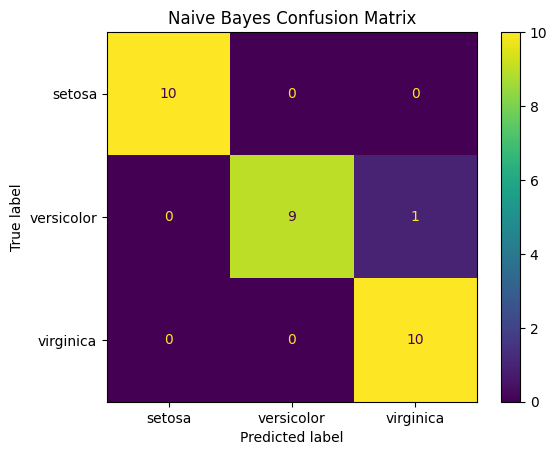

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = data.target_names)

import matplotlib.pyplot as plt

plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [10]:
y_prob = nb_model.predict_proba(X_test)

print(y_prob[:5])

[[1.00000000e+000 2.10423610e-020 1.24046690e-025]
 [8.47878473e-143 8.77457913e-002 9.12254209e-001]
 [2.60594992e-036 9.99999490e-001 5.10180517e-007]
 [1.34650506e-036 9.99999567e-001 4.32500853e-007]
 [1.00000000e+000 6.60692071e-021 6.79224134e-026]]


In [12]:
nb_model.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
nb_model.predict_proba(X)

array([[1.00000000e+000, 1.63139388e-020, 1.57464860e-025],
       [1.00000000e+000, 1.70685174e-019, 3.87553341e-025],
       [1.00000000e+000, 1.04826323e-020, 6.42545263e-026],
       [1.00000000e+000, 1.63884148e-019, 5.86838677e-025],
       [1.00000000e+000, 4.71888951e-021, 7.13926025e-026],
       [1.00000000e+000, 4.37632032e-016, 4.96581335e-021],
       [1.00000000e+000, 1.35938825e-019, 8.36577210e-025],
       [1.00000000e+000, 8.22324399e-020, 4.81931051e-025],
       [1.00000000e+000, 9.67083571e-020, 3.64180841e-025],
       [1.00000000e+000, 2.75194583e-020, 1.42504725e-025],
       [1.00000000e+000, 7.62788494e-020, 1.33697848e-024],
       [1.00000000e+000, 2.13078143e-019, 1.26889289e-024],
       [1.00000000e+000, 8.81216472e-021, 4.67667584e-026],
       [1.00000000e+000, 5.52460485e-022, 1.38338706e-026],
       [1.00000000e+000, 6.30774268e-021, 1.12954207e-024],
       [1.00000000e+000, 6.19925631e-019, 1.77295336e-022],
       [1.00000000e+000, 9.75621853e-019

In [14]:
print("Class prior probabilities:")
print(nb_model.class_prior_)

print("\nClass means:")
print(nb_model.theta_)

print("\nClass variances:")
print(nb_model.var_)

Class prior probabilities:
[0.33333333 0.33333333 0.33333333]

Class means:
[[4.985  3.415  1.4775 0.255 ]
 [5.93   2.75   4.2525 1.32  ]
 [6.61   2.98   5.58   2.04  ]]

Class variances:
[[0.092775   0.155275   0.02524375 0.012975  ]
 [0.2216     0.093      0.19149375 0.0341    ]
 [0.4574     0.1221     0.3236     0.0704    ]]


In [15]:
sample = X_test[0].reshape(1, -1)

print("Flower measurements:")
print(sample)

print("\nActual class:")
print(data.target_names[y_test[0]])

print("\nPredicted class:")
prediction = nb_model.predict(sample)[0]
print(data.target_names[prediction])

print("\nClass probabilities:")
probabilities = nb_model.predict_proba(sample)[0]

for name, probability in zip(data.target_names, probabilities):
    print(f"{name}: {probability:.4f}")

Flower measurements:
[[4.4 3.  1.3 0.2]]

Actual class:
setosa

Predicted class:
setosa

Class probabilities:
setosa: 1.0000
versicolor: 0.0000
virginica: 0.0000


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

